In [1]:
import awkward as ak
import uproot

import matplotlib.pyplot as plt

import uproot

import hist

In [2]:
file_list = [line.strip("\n") + ":events" for line in open("filelists/run2_slimmed_TT.txt")]

In [3]:
f = uproot.concatenate(file_list[0:50])

In [4]:
overallcut= (f.ak4_HT > 500) & (f.jmds6332 < 1.25)
good_ev = f[overallcut]
cut = (good_ev.jtrip_masym < 0.15) & (good_ev.jtrip_mds < 0.175) & (good_ev.jtrip_delta > 250)
mass = ak.flatten(good_ev.jtrip_mass[cut])

In [5]:
h_mass = (
            hist.Hist.new
            .StrCat(["DeltaGr250"], growth=True, name="cuts")
            .Reg(1000, 100, 300, name="mass", label="Trijet Invariant Mass")
            .Weight()
        )

h_mass.fill(mass=mass,cuts="DeltaGr250")

Hist(
  StrCategory(['DeltaGr250'], growth=True, name='cuts'),
  Regular(1000, 100, 300, name='mass', label='Trijet Invariant Mass'),
  storage=Weight()) # Sum: WeightedSum(value=286, variance=286) (WeightedSum(value=373, variance=373) with flow)

In [6]:
h_mass = h_mass["DeltaGr250",:]

In [7]:
h_mass = h_mass/h_mass.sum().value

In [8]:
f = uproot.open("jec_test_1.root")

In [9]:
hr3 = f["mass/" + "TTbar"].to_hist()['DeltaGr250',:]

In [10]:
hr3 = hr3/hr3.sum().value

In [11]:
f = uproot.open("tight_jet_constraint.root")

In [12]:
hr_raw = f["mass/" + "TTbar"].to_hist()['DeltaGr250',:]

In [13]:
hr_raw = hr_raw/hr_raw.sum().value

In [14]:
import mplhep as hep
hep.style.use("CMS")

In [15]:
import iminuit.cost
import numpy as np

In [16]:
h1_plt = h_mass[::45j]
h2_plt = hr3[::45j]
h3_plt = hr_raw[::45j]

In [17]:
def f(x, background, mu, gamma):
    return (
        background
        + (1 - background) * gamma**2 / ((x - mu) ** 2 + gamma**2) / np.pi / gamma
    )
def gauss(x, a,b,c):
    return a*np.exp(-((x-b)**2/(2*c**2)))
def gauss_tail(x, a,b,c,e):
    return a*np.exp(-((x-b)**2/(2*c**2))) + e

In [15]:
len(h1_plt.values())

22

In [18]:
fit1 = h1_plt[4:11]
loss1 = iminuit.cost.LeastSquares(
    fit1.axes[0].centers, fit1.values() , np.sqrt(fit1.variances()), gauss
)
loss1.mask = fit1.variances() > 0
minimizer = iminuit.Minuit(loss1,a=0.2,b=172,c=15)
minimizer.migrad()
minimizer.hesse()

┌─────────────────────────────────────────────────────────────────────────┐
│                                Migrad                                   │
├──────────────────────────────────┬──────────────────────────────────────┤
│ FCN = 2.723 (χ²/ndof = 0.7)      │              Nfcn = 72               │
│ EDM = 2.67e-07 (Goal: 0.0002)    │                                      │
├──────────────────────────────────┼──────────────────────────────────────┤
│          Valid Minimum           │   Below EDM threshold (goal x 10)    │
├──────────────────────────────────┼──────────────────────────────────────┤
│      No parameters at limit      │           Below call limit           │
├──────────────────────────────────┼──────────────────────────────────────┤
│             Hesse ok             │         Covariance accurate          │
└──────────────────────────────────┴──────────────────────────────────────┘
┌───┬──────┬───────────┬───────────┬────────────┬────────────┬─────────┬─────────┬───────┐
│   │ Name │   Value   │ Hesse Err │ Minos Err- │ Minos Err+ │ Limit-  │ Limit+  │ Fixed │
├───┼──────┼───────────┼───────────┼────────────┼────────────┼─────────┼─────────┼───────┤
│ 0 │ a    │   0.186   │   0.017   │            │            │         │         │       │
│ 1 │ b    │   169.3   │    1.2    │            │            │         │         │       │
│ 2 │ c    │   16.1    │    1.3    │            │            │         │         │       │
└───┴──────┴───────────┴───────────┴────────────┴────────────┴─────────┴─────────┴───────┘
┌───┬───────────────────────────────┐
│   │         a         b         c │
├───┼───────────────────────────────┤
│ a │  0.000288  -0.76e-3 -15.59e-3 │
│ b │  -0.76e-3      1.52       0.1 │
│ c │ -15.59e-3       0.1      1.79 │
└───┴───────────────────────────────┘

In [27]:
fit2 = h2_plt[5:12]
loss2 = iminuit.cost.LeastSquares(
    fit2.axes[0].centers, fit2.values() , np.sqrt(fit2.variances()), gauss
)
loss2.mask = fit2.variances() > 0
minimizer2 = iminuit.Minuit(loss2,a=0.1,b=160,c=2)
minimizer2.migrad()
minimizer2.hesse()

┌─────────────────────────────────────────────────────────────────────────┐
│                                Migrad                                   │
├──────────────────────────────────┬──────────────────────────────────────┤
│ FCN = 54.63 (χ²/ndof = 13.7)     │              Nfcn = 183              │
│ EDM = 3.24e-07 (Goal: 0.0002)    │                                      │
├──────────────────────────────────┼──────────────────────────────────────┤
│          Valid Minimum           │   Below EDM threshold (goal x 10)    │
├──────────────────────────────────┼──────────────────────────────────────┤
│      No parameters at limit      │           Below call limit           │
├──────────────────────────────────┼──────────────────────────────────────┤
│             Hesse ok             │         Covariance accurate          │
└──────────────────────────────────┴──────────────────────────────────────┘
┌───┬──────┬───────────┬───────────┬────────────┬────────────┬─────────┬─────────┬───────┐
│   │ Name │   Value   │ Hesse Err │ Minos Err- │ Minos Err+ │ Limit-  │ Limit+  │ Fixed │
├───┼──────┼───────────┼───────────┼────────────┼────────────┼─────────┼─────────┼───────┤
│ 0 │ a    │  0.1252   │  0.0013   │            │            │         │         │       │
│ 1 │ b    │  179.42   │   0.21    │            │            │         │         │       │
│ 2 │ c    │   20.55   │   0.27    │            │            │         │         │       │
└───┴──────┴───────────┴───────────┴────────────┴────────────┴─────────┴─────────┴───────┘
┌───┬───────────────────────────────┐
│   │         a         b         c │
├───┼───────────────────────────────┤
│ a │  1.64e-06  -40.2e-6 -236.3e-6 │
│ b │  -40.2e-6    0.0439      0.02 │
│ c │ -236.3e-6      0.02      0.07 │
└───┴───────────────────────────────┘

In [20]:
fit3 = h3_plt[4:11]
loss3 = iminuit.cost.LeastSquares(
    fit3.axes[0].centers, fit3.values() , np.sqrt(fit3.variances()), gauss
)
loss3.mask = fit3.variances() > 0
minimizer3 = iminuit.Minuit(loss3,a=0.1,b=160,c=2)
minimizer3.migrad()
minimizer3.hesse()

┌─────────────────────────────────────────────────────────────────────────┐
│                                Migrad                                   │
├──────────────────────────────────┬──────────────────────────────────────┤
│ FCN = 2860 (χ²/ndof = 714.9)     │              Nfcn = 144              │
│ EDM = 3.09e-05 (Goal: 0.0002)    │                                      │
├──────────────────────────────────┼──────────────────────────────────────┤
│          Valid Minimum           │   Below EDM threshold (goal x 10)    │
├──────────────────────────────────┼──────────────────────────────────────┤
│      No parameters at limit      │           Below call limit           │
├──────────────────────────────────┼──────────────────────────────────────┤
│             Hesse ok             │         Covariance accurate          │
└──────────────────────────────────┴──────────────────────────────────────┘
┌───┬──────┬───────────┬───────────┬────────────┬────────────┬─────────┬─────────┬───────┐
│   │ Name │   Value   │ Hesse Err │ Minos Err- │ Minos Err+ │ Limit-  │ Limit+  │ Fixed │
├───┼──────┼───────────┼───────────┼────────────┼────────────┼─────────┼─────────┼───────┤
│ 0 │ a    │ 127.32e-3 │  0.26e-3  │            │            │         │         │       │
│ 1 │ b    │  169.57   │   0.04    │            │            │         │         │       │
│ 2 │ c    │   19.57   │   0.05    │            │            │         │         │       │
└───┴──────┴───────────┴───────────┴────────────┴────────────┴─────────┴─────────┴───────┘
┌───┬────────────────────────────┐
│   │        a        b        c │
├───┼────────────────────────────┤
│ a │  6.6e-08 -1.64e-6 -8.18e-6 │
│ b │ -1.64e-6  0.00146   0.0005 │
│ c │ -8.18e-6   0.0005  0.00211 │
└───┴────────────────────────────┘

In [25]:
x1 = np.linspace(min(loss1.x), max(loss1.x), 200)
x2 = np.linspace(min(loss2.x), max(loss2.x), 200)
x3 = np.linspace(min(loss3.x), max(loss3.x), 200)

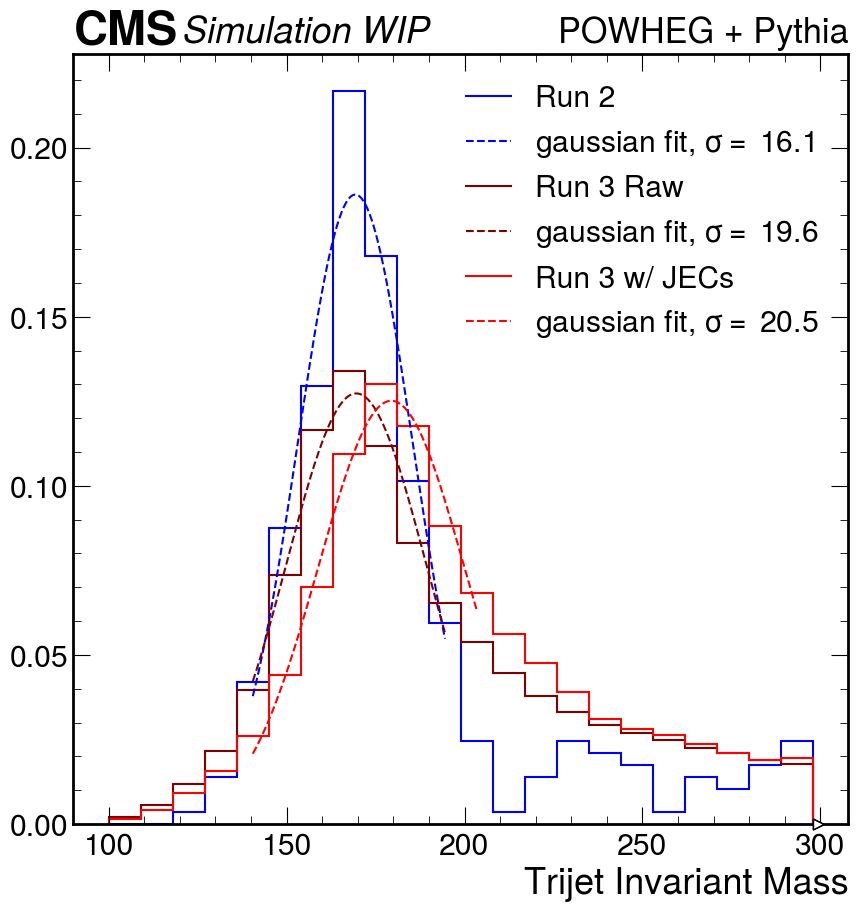

In [28]:
h1_plt.plot(color="blue",histtype="step",yerr=False,label="Run 2")
plt.plot(x1, gauss(x1, *minimizer.values),linestyle="dashed",color="blue",
         label=r"gaussian fit, $\sigma =$ " + str(round(minimizer.values["c"],1)))
h3_plt.plot(color="maroon",histtype="step",yerr=False,label="Run 3 Raw")
plt.plot(x3, gauss(x3, *minimizer3.values),linestyle="dashed",color="maroon",
         label=r"gaussian fit, $\sigma =$ " + str(round(minimizer3.values["c"],1)))
h2_plt.plot(color="red",histtype="step",yerr=False,label="Run 3 w/ JECs")
plt.plot(x2, gauss(x2, *minimizer2.values),linestyle="dashed",color="red",
         label=r"gaussian fit, $\sigma =$ " + str(round(minimizer2.values["c"],1)))
hep.cms.label(label="WIP",rlabel="POWHEG + Pythia")
plt.legend()
plt.savefig("asdf.pdf")

In [38]:
del(str)